# Layer 1: The best learning rate for one cell

In [notebook 00](00_single_cell.ipynb) every cell used a single fixed $\eta=0.005$. That is
the wrong thing to do: a cell's loss depends strongly on the learning rate, and the optimum
$\eta^\star$ is different for every $(N, D)$. Reading a scaling law off mis-tuned cells biases
the exponents (we make that concrete in [notebook 02](02_hp_transfer_law.ipynb)).

This layer finds $\eta^\star$ for **one** cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image

from scaling_laws.data import TeacherStudentRegression
from scaling_laws.live import sweep_lr_live
from scaling_laws import plotting as pl
pl.set_style()

FIGDIR = Path("../results").resolve() / "figures"
prob = TeacherStudentRegression(input_dim=32, teacher_width=256, teacher_depth=2,
                                teacher_act="gelu", noise_std=0.1, val_size=16384, seed=0)

## Sweep the learning rate

Train the same cell ($w=64$, $T=2048$) at a ladder of learning rates and watch each run's
training curve build up, coloured by $\eta$: the **hottest** rates (yellow) are noisy and stall
high, the **coldest** (purple) underfit within the step budget, and the optimum threads between.
(`hp.tune_lr_cell` runs the same sweep without the live plot.)

*(We tune only $\eta$ here; the batch size stays fixed at $b=256$. In principle it too should be
**tuned and scaled** jointly with $\eta$, see the note in [notebook 00](00_single_cell.ipynb).)*

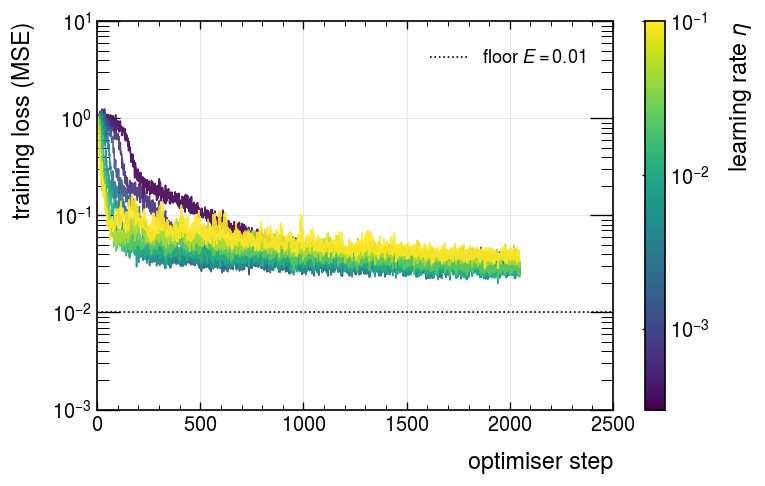

tune w=64: 100%|██████████| 9/9 [00:19<00:00,  2.22s/lr]

swept 9 learning rates at (w=64, T=2048);  eta* = 0.0039


In [2]:
lrs = np.geomspace(3e-4, 1e-1, 9)
eta_star, losses = sweep_lr_live(prob, 64, 2048 * 256, lrs)
print(f"swept {len(lrs)} learning rates at (w=64, T=2048);  eta* = {eta_star:.4f}")

Read $\eta^\star$ off the **U-curve** of final losses, a parabola in
$\log_{10}\eta$ whose vertex is the optimum.

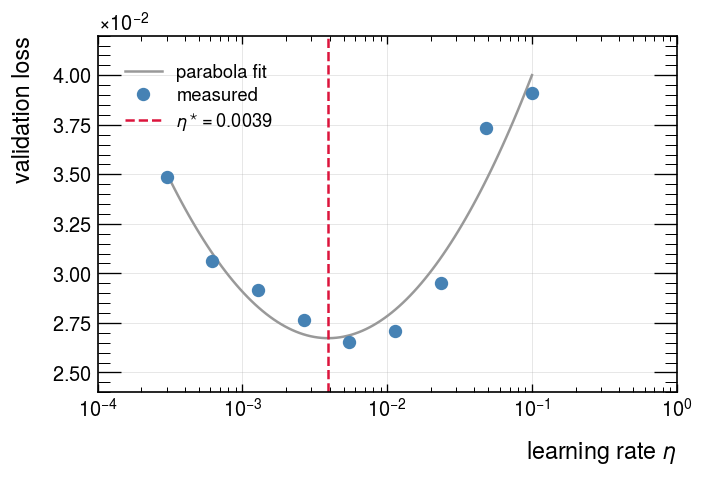

In [3]:
fig = pl.plot_lr_tuning(lrs, losses, eta_star); plt.show()

## Each cell carries its own optimum

$\eta^\star$ is not a property of the architecture alone, it is a property of the **cell**.
The compute-optimal loss at fixed model size,
$$L^\star_{\rm cell}(N,D)=\min_{\eta}\,L_{\rm final}(N,D,\eta),$$
is the *lower envelope* of many separately-tuned runs, **not** the trajectory of one run. A
single fixed-$\eta$ run lies above that envelope everywhere except at the one $D$ it was tuned
for, so as $D$ grows you must re-tune; there is no free "just train longer".

The figure below shows this construction for a fixed architecture: each curve is a run tuned
(and cosine-annealed) for one target $D$, and $L^\star_{\rm cell}$ threads their endpoints.

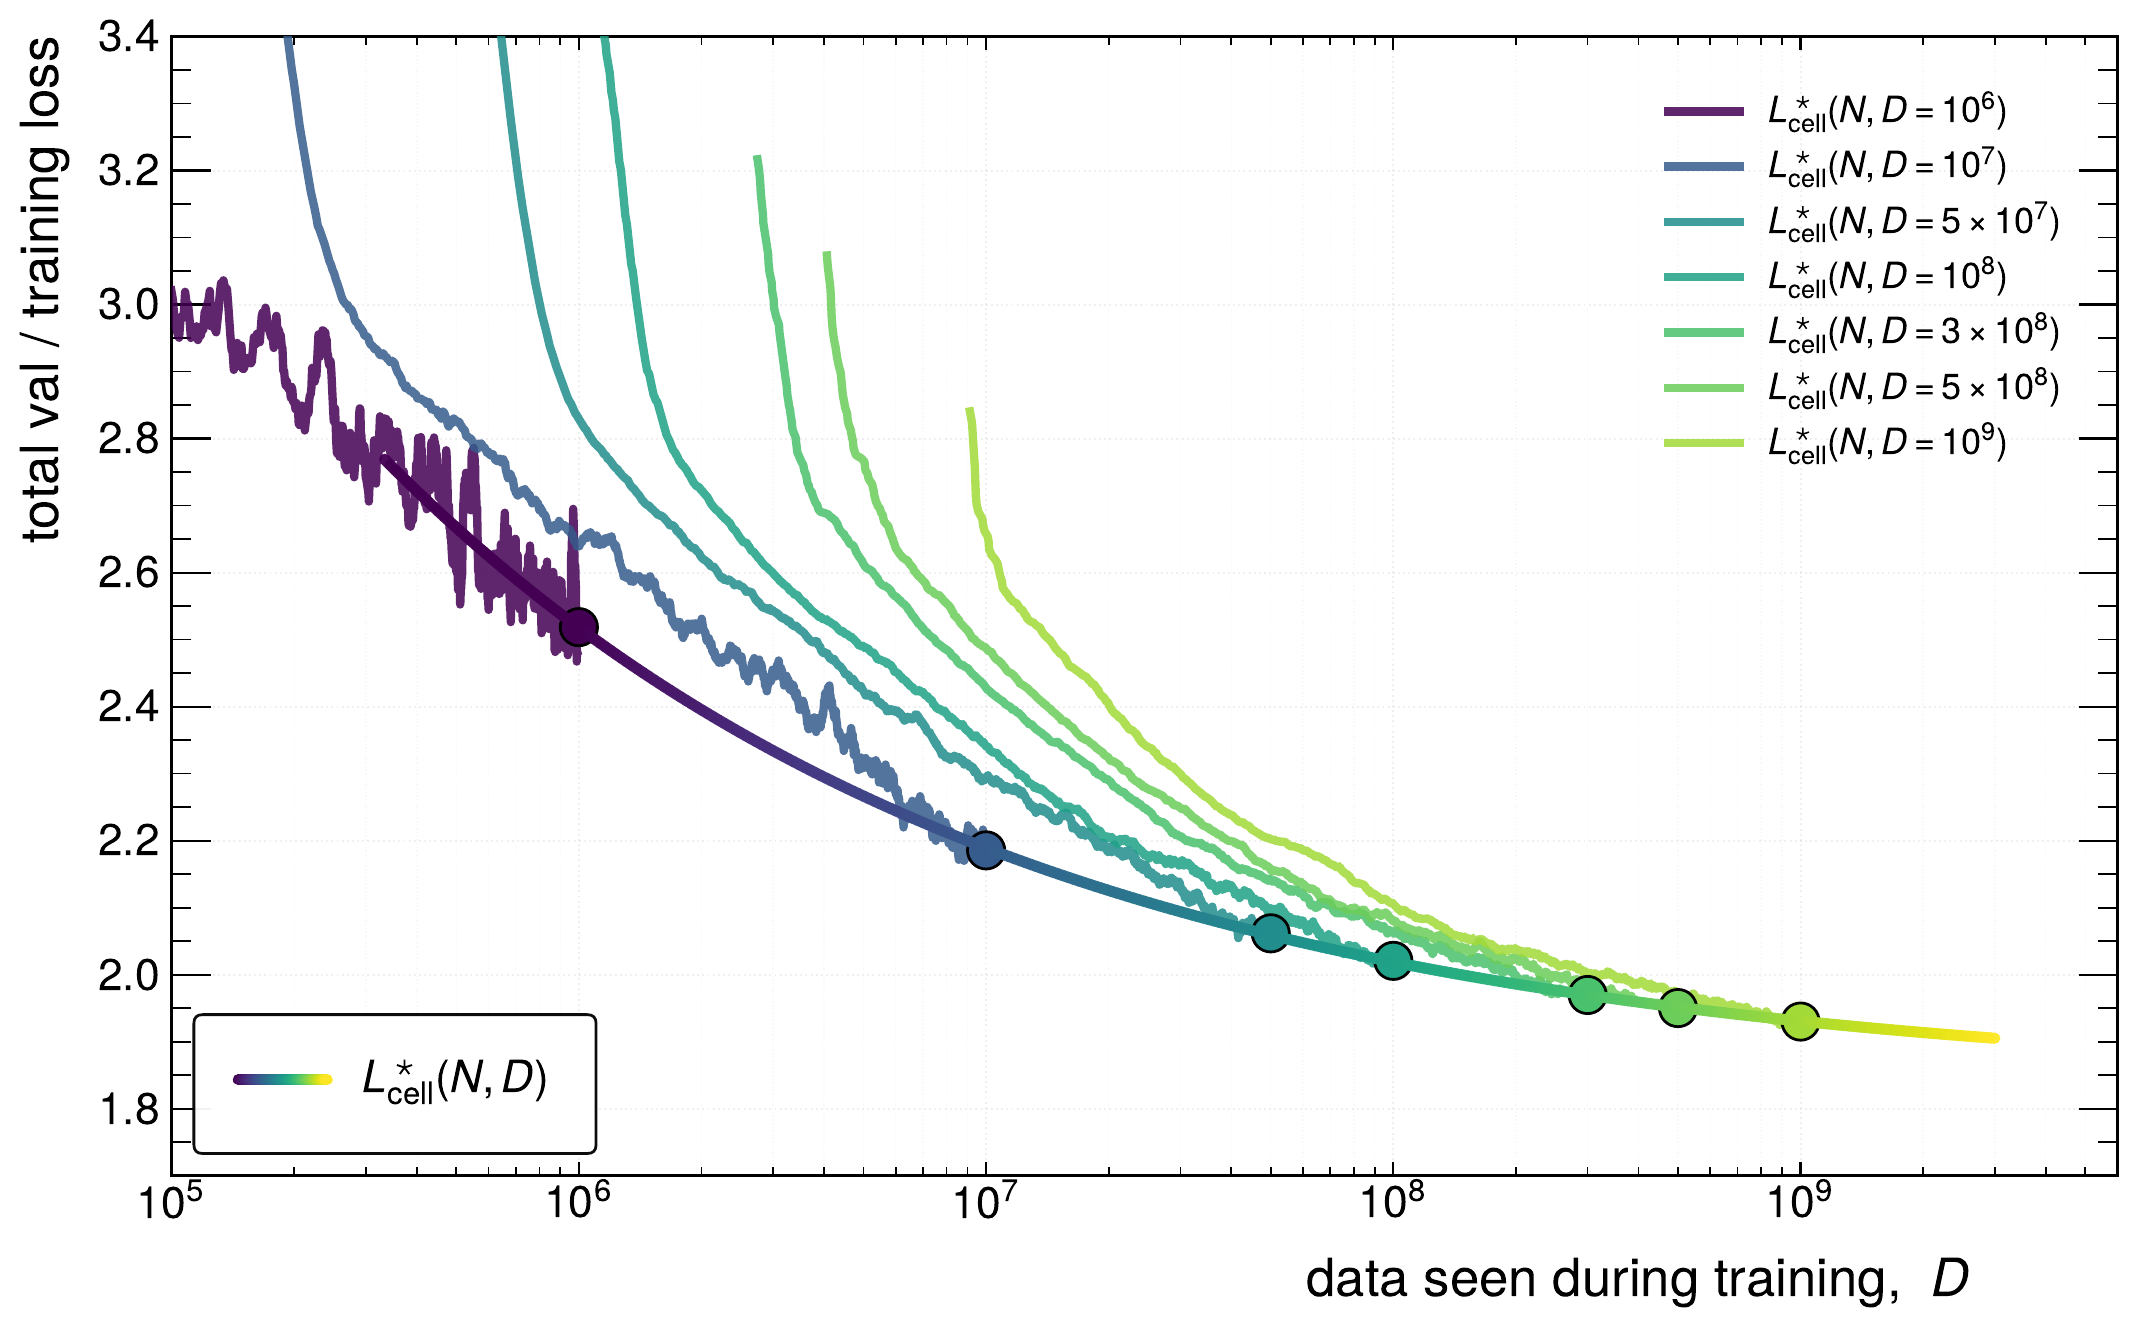

In [4]:
Image(filename=str(FIGDIR / "schedule_demo_W384_L4.png"))

**Takeaway.** One cell → one $\eta^\star$, found by a quick parabola sweep. But brute-forcing
$\eta^\star$ for every $(N,D)$ cell in a full grid is wasteful, and unnecessary, because
$\eta^\star$ moves *predictably* with width and step budget. **[Notebook 02](02_hp_transfer_law.ipynb)**
measures that movement and fits a transfer law $\eta^\star(w,T)$.